# Machine learning model

## Setup

### Imports, global constants and functions

In [225]:
import pandas as pd
import geopandas as gpd
import glob
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Polygon

In [117]:
BBOX_MAX_LAT = 39.492119
BBOX_MIN_LAT = 39.3653539
BBOX_MIN_LON = -0.343666
BBOX_MAX_LON = -0.213547

In [ ]:
BBOX: Polygon = box(BBOX_MIN_LON, BBOX_MIN_LAT, BBOX_MAX_LON, BBOX_MAX_LAT)

In [223]:
def load_parquet(path_pattern: str, engine: str ='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".

    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")

    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")

    return df

In [244]:
def draw_bbox(coastline_gdf: gpd.GeoDataFrame, poly: Polygon) -> None:
    bbox_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326") # Coordinat Reference System, WGS84 lat/long in degrees

    # Plot
    _, ax = plt.subplots(figsize=(6, 6))
    coastline_gdf.plot(ax=ax, color="darkgreen", edgecolor="black")
    bbox_gdf.boundary.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.75)

    # Add padding around bbox (200%)
    pad_lon = (BBOX_MAX_LON - BBOX_MIN_LON) * 4
    pad_lat = (BBOX_MAX_LAT - BBOX_MIN_LAT) * 4

    x_lims = (BBOX_MIN_LON - pad_lon, BBOX_MAX_LON + pad_lon)
    y_lims = (BBOX_MIN_LAT - pad_lat, BBOX_MAX_LAT + pad_lat)

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Berth bounding box")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [251]:
def plot_voyage_on_coastline(voyage_df: pd.DataFrame, coastline_gdf: gpd.GeoDataFrame, poly: Polygon, padding: float = 0.1) -> None:
    # Sort by timestamp
    voyage_df = voyage_df.sort_values(by="pos_timestamp", ascending=True, inplace=False)

    # Get voyage coord bounds
    min_lon, max_lon = voyage_df['longitude'].min(), voyage_df['longitude'].max()
    min_lat, max_lat = voyage_df['latitude'].min(), voyage_df['latitude'].max()

    # Calculate range (square window)
    lon_range = max_lon - min_lon
    lat_range = max_lat - min_lat
    full_range = max(lon_range, lat_range)

    pad = full_range * padding
    center_lon = (min_lon + max_lon) / 2
    center_lat = (min_lat + max_lat) / 2

    x_lims = (center_lon - full_range/2 - pad, center_lon + full_range/2 + pad)
    y_lims = (center_lat - full_range/2 - pad, center_lat + full_range/2 + pad)

    poly_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")

    # Single figure
    _, ax = plt.subplots(figsize=(12, 12))
    coastline_gdf.plot(ax=ax, color="darkgreen", edgecolor="black", label="Coastline")

    # Voyage
    ax.plot(
        voyage_df['longitude'], voyage_df['latitude'],
        marker='o', linestyle='-', color='blue', label="Voyage Trajectory", markersize=2, markeredgecolor="black"
    )

    # BBox on SAME axes
    poly_gdf.boundary.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.75, label="Bounding box")

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.set_aspect('equal')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Voyage: {voyage_df['voyage_id'].iloc[0]}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(
        f"Voyage: {voyage_df['voyage_id'].iloc[0]} "
        f"\nTotal traveled distance: {voyage_df['total_dist_km'].iloc[0].round(2)} km"
        f"\nDuration: {(voyage_df['duration'].iloc[0] / 3600).round(2)} hours"
        f"\nData points: {voyage_df.shape[0]}"
    )

In [275]:
def plot_all_voyages(df: pd.DataFrame, coastline_gdf: gpd.GeoDataFrame, poly: Polygon, padding: float = 0.1, max_voyages: int = 20) -> None:
    """Plot ALL unique voyages from dataframe."""
    
    unique_voyages = df['voyage_id'].unique()
    print(f"Found {len(unique_voyages)} voyages.")
    
    poly_gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")
    
    # Get overall bounds for ALL voyages
    all_lons = df['longitude']
    all_lats = df['latitude']
    min_lon, max_lon = all_lons.min(), all_lons.max()
    min_lat, max_lat = all_lats.min(), all_lats.max()

    # Single figure for ALL
    _, ax = plt.subplots(figsize=(14, 14))
    coastline_gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
    
    # Plot each voyage with different colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_voyages)))
    
    for i, voyage_id in enumerate(unique_voyages):
        voyage_data = df[df['voyage_id'] == voyage_id].sort_values('pos_timestamp')
        
        ax.plot(
            voyage_data['longitude'], voyage_data['latitude'],
            linestyle='-', linewidth=0.8,
            color=colors[i], alpha=0.3,
        )
    
    # Bounding box
    poly_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="Bounding box")
    
    ax.set_xlim((min_lon - 2, max_lon + 2))
    ax.set_ylim((min_lat - 2, max_lat + 2))
    ax.set_aspect('equal')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"All Voyages ({len(unique_voyages)}) in Bounding Box")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

Found 2874 voyages.


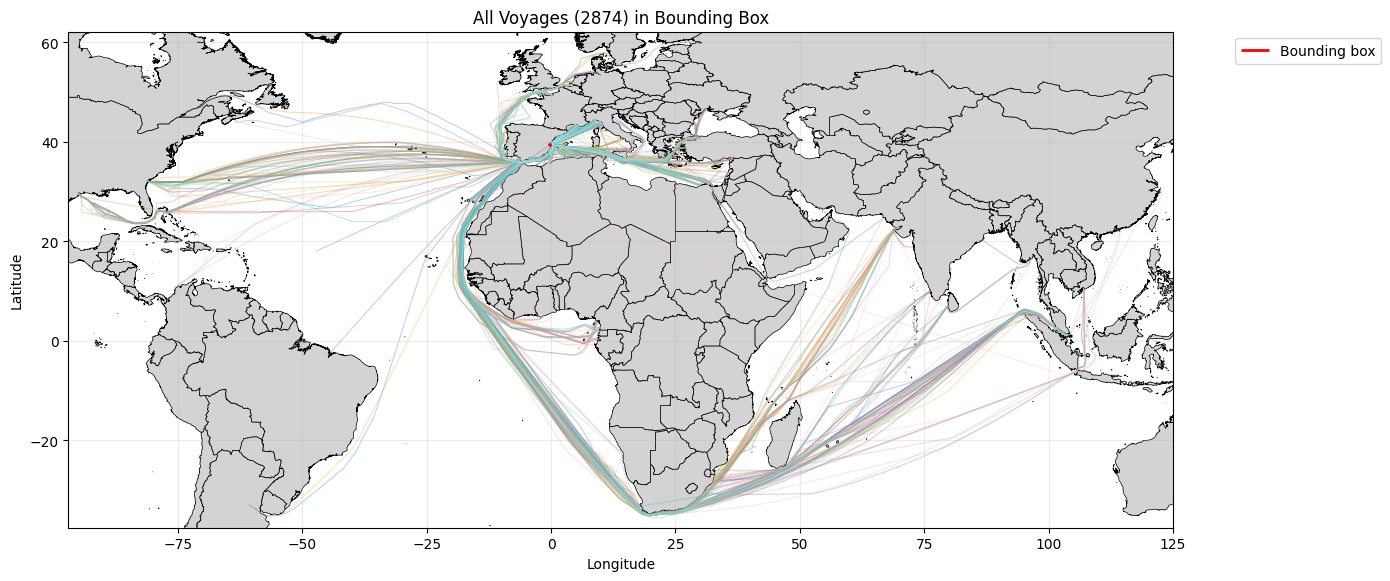

In [276]:
plot_all_voyages(cargo_ais_meta_merged, coastline, BBOX)

### Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [4]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


## Exploratory data analysis

### Inspect AIS data

In [5]:
arrivals_ais_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3311442 entries, 0 to 3311441
Data columns (total 50 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   voyage_id              object        
 1   voyage_status          object        
 2   mmsi                   int64         
 3   pos_timestamp          datetime64[ns]
 4   navigation_status      object        
 5   position_accuracy      bool          
 6   longitude              float64       
 7   latitude               float64       
 8   course_over_ground     float64       
 9   true_heading           int64         
 10  timestamp_seconds      int64         
 11  raim                   bool          
 12  rate_of_turn           float64       
 13  speed_over_ground      float64       
 14  pos_source             object        
 15  call_sign              object        
 16  name                   object        
 17  ship_type              int64         
 18  ref_point_a           

In [6]:
arrivals_ais_data.shape

(3311442, 50)

In [7]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

Sort firstly by voyage_id then pos_timestamp

In [8]:
arrivals_ais_data = arrivals_ais_data.sort_values(["voyage_id", "pos_timestamp"])

In [9]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
994258,000342cb-2f27-4092-8ae7-55e19390b31e,PENDING_DEPARTURE,227330300,2024-05-11 10:26:46,UNDEFINED,False,-0.31529,39.46143,360.0,87,...,0,0,0,,,0.0,0.0,0,00,2024-05
994259,000342cb-2f27-4092-8ae7-55e19390b31e,UNDER_WAY,227330300,2024-05-11 10:41:47,UNDEFINED,False,-0.31527,39.46144,360.0,170,...,0,0,0,,,0.0,0.0,0,00,2024-05
993863,000342cb-2f27-4092-8ae7-55e19390b31e,STOPPED,227330300,2024-05-11 11:04:56,UNDEFINED,False,-0.31527,39.46142,360.0,86,...,0,0,0,,,0.0,0.0,0,00,2024-05
993864,000342cb-2f27-4092-8ae7-55e19390b31e,UNDER_WAY,227330300,2024-05-11 11:16:56,UNDEFINED,False,-0.31528,39.46143,360.0,171,...,0,0,0,,,0.0,0.0,0,00,2024-05
993865,000342cb-2f27-4092-8ae7-55e19390b31e,STOPPED,227330300,2024-05-11 11:25:57,UNDEFINED,False,-0.31529,39.46142,360.0,169,...,0,0,0,,,0.0,0.0,0,00,2024-05


#### Remove duplicates

In [10]:
print(f"Total rows: {arrivals_ais_data.shape[0]}")
print(f"Duplicate rows: {arrivals_ais_data.duplicated().sum()}")

Total rows: 3311442
Duplicate rows: 86


In [11]:
arrivals_ais_data.drop_duplicates(keep="first", inplace=True)

#### Check for missing values

In [12]:
arrivals_ais_data.isna().sum()

voyage_id                      0
voyage_status                  0
mmsi                           0
pos_timestamp                  0
navigation_status              0
position_accuracy              0
longitude                      0
latitude                       0
course_over_ground             0
true_heading                   0
timestamp_seconds              0
raim                           0
rate_of_turn                   0
speed_over_ground              0
pos_source                     0
call_sign                      0
name                           0
ship_type                      0
ref_point_a                    0
ref_point_b                    0
ref_point_c                    0
ref_point_d                    0
position_device                0
eta                      1640039
draught                        0
destination                    0
meta_timestamp                 0
imo                            0
meta_source                    0
flag                           0
build_year

In [13]:
(arrivals_ais_data["eta"].isna().mean() * 100).round(2)

np.float64(49.53)

49.53% of AIS data doesn't have a valid ETA

### Inspect voyage META data

In [14]:
arrivals_ais_meta_data.shape

(43352, 17)

In [15]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [16]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Remove duplicates

In [17]:
print(f"Total rows: {arrivals_ais_meta_data.shape[0]}")
print(f"Duplicate rows: {arrivals_ais_meta_data.duplicated().sum()}")

Total rows: 43352
Duplicate rows: 0


#### Check for missing values

In [18]:
arrivals_ais_meta_data.isna().sum()

voyage_id                0
mmsi                     0
departure_time           0
departure_locode         0
departure_latitude       0
departure_longitude      0
arrival_time             0
arrival_locode           0
arrival_latitude         0
arrival_longitude        0
prev_voyage_id           0
next_voyage_id           0
departed_port_call_id    0
arrived_port_call_id     0
duration                 0
arrival_country          0
arrival_date             0
dtype: int64

### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [19]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"), # column name suffix if both DataFrames contain the same column
)

In [20]:
ais_meta_merged.shape

(3311356, 66)

In [21]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

### Check if mmsi_ais and mmsi_meta are equal

In [22]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")

mmsi_ais and mmsi_meta match in 100.00% of merged rows


#### Good, drop mmsi_meta column and rename mmsi_ais to mmsi

In [23]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Determining the actual time of arrival

#### To determine the actual time of arrival (ATA) we will use a simplistic definition of "if vessel is in bounding box, it's ready to berthe".

/tmp/ipykernel_7014/2507580203.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


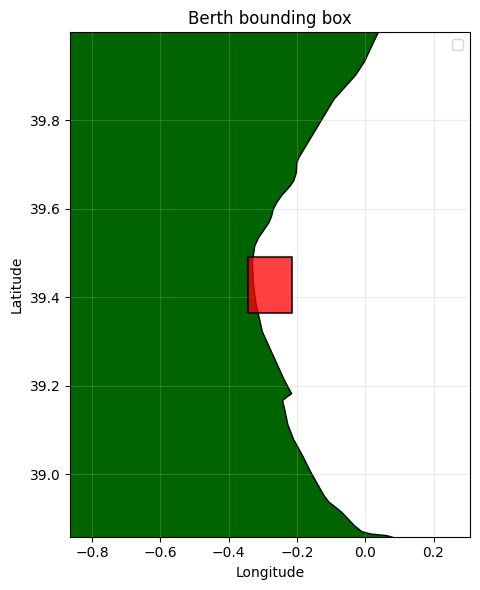

In [245]:
coastline = gpd.read_file("./data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
draw_bbox(coastline, BBOX)

## Pre-processing

### Defining the population

#### Filter out non-commercial vessels

In [25]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [26]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
61,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:12:52,UNDER_WAY_USING_ENGINES,True,-5.526118,35.875667,223.899994,40,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
62,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:29:47,MOORED,True,-5.526198,35.875515,220.800003,39,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
63,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 10:58:31,MOORED,True,-5.526250,35.875617,220.800003,41,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
64,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 11:16:30,MOORED,True,-5.526217,35.875567,220.800003,41,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
65,000f779b-5cb3-45da-a836-65e36c713e57,PENDING_DEPARTURE,271044070,2024-05-28 11:31:31,MOORED,True,-5.526200,35.875533,220.800003,39,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30


#### Filter out voyages with invalid voyage status

In [27]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            50.95
PENDING_DEPARTURE    31.41
STOPPED              16.97
COMPLETED             0.66
Name: proportion, dtype: float64

In [28]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY", "STOPPED"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
120,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
121,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
122,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
123,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30
124,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,ESVLC,39.447783,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30


#### Filter out voyages with missing MMSI

In [29]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI: {voyages_with_valid_mmsi_pct:.2f}%")

Voyages with valid MMSI: 100.00%


#### Filter out AIS data past actual time of arrival to isolate the voyage from the "waiting to be berthed" stage

In [30]:
max_lat = 39.492119
min_lat = 39.3653539
min_lon = -0.343666
max_lon = -0.213547

in_bbox = (
    (cargo_ais_meta_merged["latitude"].between(min_lat, max_lat)) &
    (cargo_ais_meta_merged["longitude"].between(min_lon, max_lon))
)

cargo_ais_meta_merged["in_bbox"] = in_bbox

In [31]:
cargo_ais_meta_merged["in_bbox"].sample(10)

1673681    False
2431108    False
1912108     True
1802619    False
2552760     True
1299011    False
176609     False
400939      True
2675102    False
190146     False
Name: in_bbox, dtype: bool

In [32]:
cargo_ais_meta_merged.iloc[359223]

voyage_id               8843d835-e502-4ad8-9605-cb6d5989508b
voyage_status                                      UNDER_WAY
mmsi                                               538004911
pos_timestamp                            2024-06-04 07:52:06
navigation_status                    UNDER_WAY_USING_ENGINES
                                        ...                 
arrived_port_call_id                                        
duration                                           1968843.0
arrival_country                                           ES
arrival_date                                      2024-06-13
in_bbox                                                False
Name: 1788559, Length: 66, dtype: object

Above we see that voyage_status: STOPPED, navigation_status: AT_ANCHOR, in_bbox: True, yet tta_hours: 42.156111.
<br>This means the arrival_time is when it HAS berthed and not when it arrived outside the harbor and is waiting for a berthing spot.
<br>Trim all remaining data points after in_bbox becomes true.

In [33]:
# Sort by voyage and time first
df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

# For each voyage, find the first index where in_bbox is True
first_in = (
    df[df["in_bbox"]]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_in_bbox_time")
)

# Join back to df
df = df.merge(first_in, on="voyage_id", how="left")

# Only keep rows before and the exact row where in_bbox true
mask = (df["pos_timestamp"] <= df["first_in_bbox_time"])

cargo_ais_meta_merged = df[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34


#### Filter out voyages with invalid navigation statuses

In [34]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              95.45
AT_ANCHOR                             2.23
MOORED                                1.56
UNDER_WAY_SAILING                     0.52
NOT_UNDER_COMMAND                     0.14
CONSTRAINED_BY_HER_DRAUGHT            0.04
RESTRICTED_MANEUVERABILITY            0.03
UNDEFINED                             0.02
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.01
AGROUND                               0.00
Name: proportion, dtype: float64

In [35]:
VALID_NAVIGATION_STATUSES = [
       'UNDER_WAY_USING_ENGINES', 'MOORED', 'AT_ANCHOR',
       'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE']

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34


In [36]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Outlier detection and removal

#### Duration

In [37]:
print(f"Duration (minutes): \n{cargo_ais_meta_merged["duration"].describe().div(60).round(2)}")

Duration (minutes): 
count      7648.00
mean      18136.02
std       18412.03
min           2.00
25%        3511.10
50%        9446.25
75%       35912.32
max      187349.28
Name: duration, dtype: float64


In [38]:
lower_q = 0.01
upper_q = 0.99

q_low  = cargo_ais_meta_merged["duration"].quantile(lower_q)
q_high = cargo_ais_meta_merged["duration"].quantile(upper_q)

mask = (cargo_ais_meta_merged["duration"] >= q_low) & (cargo_ais_meta_merged["duration"] <= q_high)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()

In [39]:
print(f"Duration (minutes): \n{cargo_ais_meta_merged["duration"].describe().div(60).round(2)}")

Duration (minutes): 
count     7562.10
mean     18186.29
std      18035.96
min        220.50
25%       3656.55
50%       9622.73
75%      35935.22
max      97635.92
Name: duration, dtype: float64


#### SOG

In [40]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    453726.000000
mean         12.728731
std           5.241297
min           0.000000
25%          10.600000
50%          13.400000
75%          16.500000
max         102.300003
Name: speed_over_ground, dtype: float64

Max SOG is extremely high, lets plot it

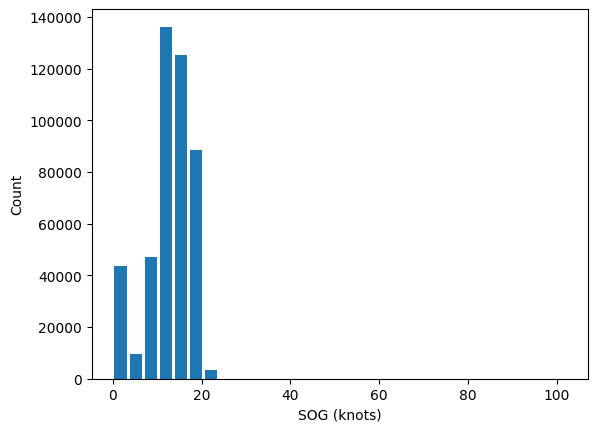

In [41]:
plt.hist(cargo_ais_meta_merged["speed_over_ground"], rwidth=0.8, bins=30)
plt.xlabel("SOG (knots)")
plt.ylabel("Count")
plt.show()

We also have lots of entries with SOG of 0, keep them as is for now and just remove  the upper 1% quantile outliers.

In [42]:
upper_q = 0.99

q_high = cargo_ais_meta_merged["speed_over_ground"].quantile(upper_q)

mask = cargo_ais_meta_merged["speed_over_ground"] <= q_high
cargo_ais_meta_merged = cargo_ais_meta_merged[mask]

In [43]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    449672.000000
mean         12.635257
std           5.040090
min           0.000000
25%          10.600000
50%          13.300000
75%          16.400000
max          20.299999
Name: speed_over_ground, dtype: float64

We now get way more realistic SOG values.

#### Coords

Longitude is expected to be [-180;180].

In [44]:
cargo_ais_meta_merged["longitude"].describe()

count    449672.000000
mean          3.043586
std          24.170278
min         -95.012603
25%          -6.312437
50%          -0.003707
75%           7.553865
max         123.033823
Name: longitude, dtype: float64

Latitude is expected to be [-90;90].

In [45]:
cargo_ais_meta_merged["latitude"].describe()

count    449672.000000
mean         26.982274
std          21.707269
min         -35.536462
25%          26.476939
50%          36.497215
75%          39.310195
max          60.196253
Name: latitude, dtype: float64

No impossible coords detected.

Lets look at a data sample with a stop mid-journey

## Feature engineering

#### Calculate delta longitude and latitude

Covert to scalar distance (km) from degrees (mixes direction and scale)?

In [46]:
cargo_ais_meta_merged["delta_lon"] = cargo_ais_meta_merged.groupby("voyage_id")["longitude"].diff()
cargo_ais_meta_merged["delta_lon"].describe()

count    446383.000000
mean         -0.031662
std           0.358555
min        -115.782982
25%          -0.078703
50%          -0.023317
75%           0.048849
max          51.788637
Name: delta_lon, dtype: float64

In [47]:
cargo_ais_meta_merged["delta_lat"] = cargo_ais_meta_merged.groupby("voyage_id")["latitude"].diff()
cargo_ais_meta_merged["delta_lat"].describe()

count    446383.000000
mean          0.017061
std           0.293414
min         -80.748948
25%          -0.020146
50%           0.010673
75%           0.052187
max          80.516758
Name: delta_lat, dtype: float64

Distance in km using haversine

In [48]:
import numpy as np

R = 6371.0  # Earth radius in km

cargo_ais_meta_merged = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

lat1 = np.radians(cargo_ais_meta_merged["latitude"].shift(1))   # global shift
dlat = np.radians(cargo_ais_meta_merged["delta_lat"])
dlon = np.radians(cargo_ais_meta_merged["delta_lon"])

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat1 + dlat) * np.sin(dlon / 2)**2

c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

cargo_ais_meta_merged["delta_dist_km"] = R * c


In [49]:
cargo_ais_meta_merged["delta_dist_km"].describe()

count    446383.000000
mean         14.039884
std          44.975571
min           0.000000
25%           5.641863
50%           7.933226
75%          13.016498
max       12876.494261
Name: delta_dist_km, dtype: float64

In [50]:
sus = cargo_ais_meta_merged.sort_values("delta_dist_km", ascending=False).copy().head()
sus[["voyage_id","pos_timestamp","latitude","longitude","delta_dist_km","speed_over_ground"]]

,voyage_id,pos_timestamp,latitude,longitude,delta_dist_km,speed_over_ground
446576,a9b6885e-0dec-4da5-9d60-f5b46bf3177a,2024-09-29 10:31:43,29.840950,-12.198432,12876.494261,15.1
79247,1c05b473-b1d8-4a82-a142-5a706a01db43,2024-02-07 22:38:49,-26.565022,34.624563,9753.374656,19.1
79246,1c05b473-b1d8-4a82-a142-5a706a01db43,2024-02-07 22:16:23,54.183927,-5.106110,9737.352950,10.7
542190,c9fafcfb-af11-401f-81b1-3625e49ad252,2024-02-26 14:54:42,34.996833,-21.408000,6698.287734,10.1
542189,c9fafcfb-af11-401f-81b1-3625e49ad252,2024-02-26 12:57:40,-22.350705,-40.840792,6680.852194,11.7


Remove any data points with an unrealistically high max delta dist km

In [51]:
MAX_DELTA_DIST_KM = 500

mask = cargo_ais_meta_merged["delta_dist_km"] > MAX_DELTA_DIST_KM
cargo_ais_meta_merged = cargo_ais_meta_merged.loc[~mask]
cargo_ais_meta_merged["delta_dist_km"].describe()

count    446241.000000
mean         13.603209
std          20.949459
min           0.000000
25%           5.641197
50%           7.931535
75%          13.004249
max         496.039636
Name: delta_dist_km, dtype: float64

In [52]:
cargo_ais_meta_merged["total_dist_km"] = cargo_ais_meta_merged.groupby("voyage_id")["delta_dist_km"].transform("sum")

In [53]:
cargo_ais_meta_merged["total_dist_km"].describe()

count    449530.000000
mean       7239.654037
std        7797.919898
min           0.000000
25%        1012.436811
50%        3223.378682
75%       15388.600676
max       24119.576512
Name: total_dist_km, dtype: float64

In [54]:
cargo_ais_meta_merged[cargo_ais_meta_merged["total_dist_km"] == cargo_ais_meta_merged["total_dist_km"].max()]

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time,delta_lon,delta_lat,delta_dist_km,total_dist_km
191990,45aa18f5-62f5-4a2f-917e-a7cf68de2893,STOPPED,538007486,2024-02-13 10:18:58,MOORED,False,121.866907,29.936783,243.0,291,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,NaN,NaN,NaN,24119.576512
191991,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-02-14 03:41:23,UNDER_WAY_USING_ENGINES,False,121.902415,29.948090,80.0,75,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,0.035508,0.011307,3.645038,24119.576512
191992,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-02-14 04:55:54,UNDER_WAY_USING_ENGINES,False,122.176300,29.888078,156.0,161,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,0.273885,-0.060012,27.226620,24119.576512
191993,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-02-14 05:35:47,UNDER_WAY_USING_ENGINES,False,122.269807,29.779588,129.0,127,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,0.093507,-0.108490,15.062551,24119.576512
191994,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-02-14 05:59:59,UNDER_WAY_USING_ENGINES,False,122.323173,29.740318,135.0,143,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,0.053367,-0.039270,6.753151,24119.576512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193285,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-03-22 00:01:38,UNDER_WAY_USING_ENGINES,False,-0.035118,39.401675,285.0,288,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,-0.068983,0.015877,6.185158,24119.576512
193286,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-03-22 00:17:38,UNDER_WAY_USING_ENGINES,False,-0.099363,39.413753,277.0,276,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,-0.064245,0.012078,5.680629,24119.576512
193287,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-03-22 00:33:30,UNDER_WAY_USING_ENGINES,False,-0.158863,39.415695,270.0,272,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,-0.059500,0.001942,5.115960,24119.576512
193288,45aa18f5-62f5-4a2f-917e-a7cf68de2893,UNDER_WAY,538007486,2024-03-22 00:48:49,UNDER_WAY_USING_ENGINES,False,-0.198638,39.417095,284.0,295,...,,3255666.0,ES,2024-03-22,False,2024-03-22 01:05:48,-0.039775,0.001400,3.420370,24119.576512


/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


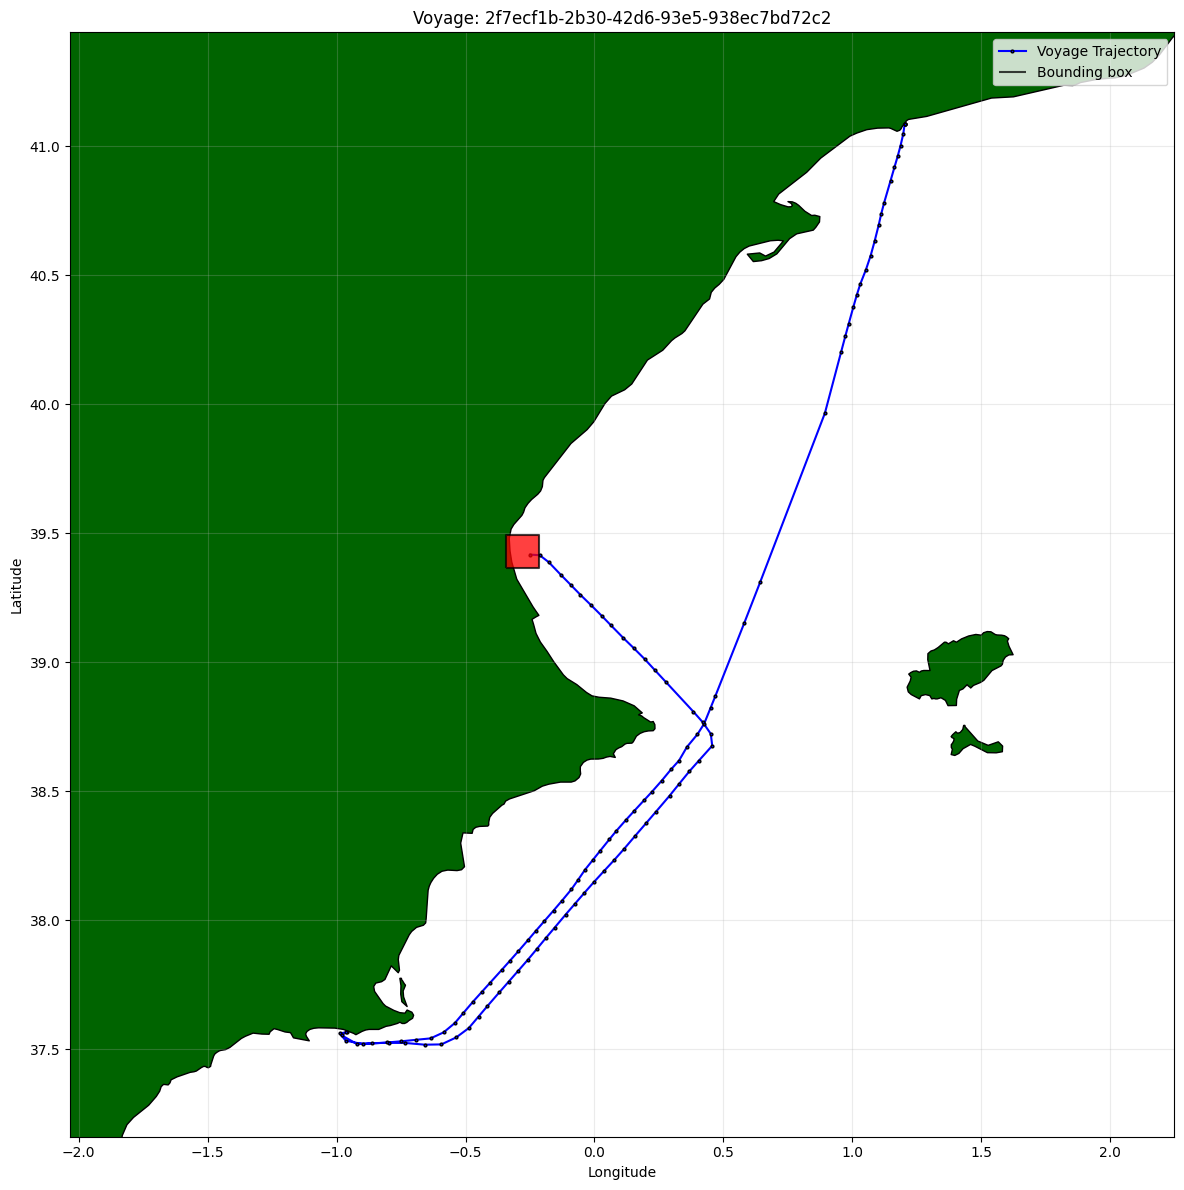

Voyage: 2f7ecf1b-2b30-42d6-93e5-938ec7bd72c2 
Total traveled distance: 768.61 km
Duration: 59.73 hours
Data points: 116


In [252]:
voyage_df = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == "2f7ecf1b-2b30-42d6-93e5-938ec7bd72c2"].copy()
plot_voyage_on_coastline(voyage_df, coastline, BBOX)

#### Calculate course deviation and include as feature<br>
Course deviation helps accomodate for wind and waves physically causing the vessel to mode in a different direction than where it's pointing.<br>
Vessel can't deviate by more than 360 degrees total, so map to -180,180 degrees.

In [57]:
diff = cargo_ais_meta_merged["course_over_ground"] - cargo_ais_meta_merged["true_heading"]
cargo_ais_meta_merged["deg_off_course"] = ((diff + 180) % 360) - 180
cargo_ais_meta_merged["deg_off_course"].describe()

count    449530.000000
mean         -0.537838
std          35.281880
min        -180.000000
25%          -1.500000
50%           0.000000
75%           1.799988
max         179.900002
Name: deg_off_course, dtype: float64

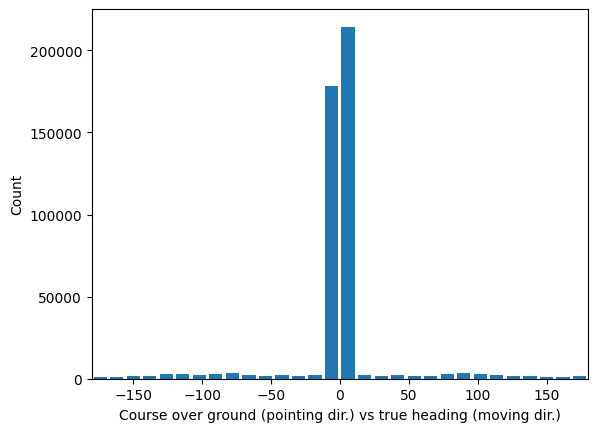

In [58]:
plt.hist(cargo_ais_meta_merged["deg_off_course"], rwidth=0.8, bins=30)
plt.xlim(-180, 180)
plt.xlabel("Course over ground (pointing dir.) vs true heading (moving dir.)")
plt.ylabel("Count")
plt.show()

### Include time-to-arrival (TTA) as feature (arrival time - timestamp)

In [59]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["first_in_bbox_time"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                       449530
mean     5 days 04:38:40.374401615
std      7 days 05:01:27.118253032
min                0 days 00:00:00
25%         0 days 14:08:21.250000
50%                2 days 02:38:13
75%         6 days 13:10:29.250000
max               64 days 04:52:28
Name: tta, dtype: object

In [60]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    449530.00
mean        124.64
std         173.02
min           0.00
25%          14.14
50%          50.64
75%         157.17
max        1540.87
Name: tta_hours, dtype: float64

Filter out voyages with a total distance less than 22 km (nearest port) or with tta_hours < (22 km/max_speed)

In [61]:
TTA_LIM = 22 / (cargo_ais_meta_merged["speed_over_ground"].max() * 1.852)

df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"]).copy()
first_tta = df.groupby("voyage_id")["tta_hours"].first()

mask = first_tta < TTA_LIM
voyage_ids_start_lt_lim = first_tta[mask].index
# assign to cargo ais meta merged if wanting to use this version
voyages_start_lt_tta = df[df["voyage_id"].isin(voyage_ids_start_lt_lim)].copy()

print(f"{voyages_start_lt_tta["tta_hours"].describe()} \n")
print(f"{(voyages_start_lt_tta["duration"].describe() / 3600).round(2)} \n")
print(f"{voyages_start_lt_tta["total_dist_km"].describe()} \n")


count    363.000000
mean       0.005028
std        0.039264
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.535278
Name: tta_hours, dtype: float64 

count      0.10
mean      40.21
std       67.62
min        3.70
25%       10.88
50%       21.41
75%       44.63
max      769.40
Name: duration, dtype: float64 

count    363.000000
mean       1.687060
std       22.096160
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      298.086898
Name: total_dist_km, dtype: float64 



In [62]:
DIST_LIM_UPPER = 22

# Find voyage_ids with less than 22 km total distance
mask = cargo_ais_meta_merged["total_dist_km"] < DIST_LIM_UPPER
voyage_ids_lt_dist_lim = cargo_ais_meta_merged.loc[mask, "voyage_id"].unique()

# Keep only voyages that are NOT in that list
cargo_ais_meta_merged = cargo_ais_meta_merged[
    ~cargo_ais_meta_merged["voyage_id"].isin(voyage_ids_lt_dist_lim)
].copy()

print(cargo_ais_meta_merged["total_dist_km"].describe())

count    448411.000000
mean       7257.693444
std        7799.267220
min          22.148848
25%        1017.342830
50%        3226.502576
75%       15388.600676
max       24119.576512
Name: total_dist_km, dtype: float64


#### Include accumulative and remaining TTA as feature

In [63]:
cargo_ais_meta_merged = cargo_ais_meta_merged.sort_values(['voyage_id', 'pos_timestamp'])

# Group by voyage and accumulate distance traveled
cargo_ais_meta_merged['accumulated_dist_km'] = (
    cargo_ais_meta_merged
    .groupby('voyage_id')['delta_dist_km']
    .cumsum()
)

# Remaining distance
cargo_ais_meta_merged['remaining_dist_km'] = (
    cargo_ais_meta_merged['total_dist_km'] -
    cargo_ais_meta_merged['accumulated_dist_km']
)

In [64]:
cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == cargo_ais_meta_merged["voyage_id"].iloc[0]]["remaining_dist_km"].head()


0           NaN
1    770.207479
2    769.916247
3    764.777510
4    759.195626
Name: remaining_dist_km, dtype: float64

### Include loading_pct as feauture (draught/max_draught)

In [65]:
cargo_ais_meta_merged["draught"].describe()

count    448411.000000
mean         10.800924
std           3.307825
min           0.000000
25%           8.200000
50%          10.500000
75%          13.900000
max          25.500000
Name: draught, dtype: float64

In [66]:
(cargo_ais_meta_merged["draught"].isna().mean() * 100).round(2)

np.float64(0.0)

In [67]:
cargo_ais_meta_merged["draught_max"].describe()

count    448411.000000
mean          7.664401
std           6.314922
min           0.000000
25%           0.000000
50%           9.200000
75%          13.500000
max          19.800000
Name: draught_max, dtype: float64

In [185]:
(cargo_ais_meta_merged["draught_max"].isna().mean() * 100).round(2)

np.float64(37.35)

Since we can't divide by 0, make 0 NaN

In [69]:
import numpy as np
cargo_ais_meta_merged["draught_max"] = cargo_ais_meta_merged["draught_max"].replace(0, np.nan)

About 1/3 is missing draught_max
<br>Impute draught_max for missing vessels? Better if you don’t want to lose 1/3 of data:
<br>Group by vessel identity (e.g. mmsi or ship_type + commercial_size_class) and fill missing draught_max with a typical value in that group.​

In [70]:
cargo_ais_meta_merged["loading_pct"] = cargo_ais_meta_merged["draught"] / cargo_ais_meta_merged["draught_max"]
cargo_ais_meta_merged["loading_pct"].describe()

count    280947.000000
mean          0.842829
std           0.125112
min           0.000000
25%           0.740157
50%           0.842520
75%           0.945946
max           2.236842
Name: loading_pct, dtype: float64

In [71]:
over = cargo_ais_meta_merged[cargo_ais_meta_merged["loading_pct"] > 1.0]
over[["mmsi", "voyage_id", "draught", "draught_max"]].shape[0]

26404

### Select features

add 1 size proxy varaible

raim seems to not matter, same for rate_of_turn

Haversine fast but inaccurate

In [73]:
from geopy.distance import geodesic

def calc_remaining_dist(row):
    current = (row['latitude'], row['longitude'])
    arrival = (row['arrival_latitude'], row['arrival_longitude'])
    return geodesic(current, arrival).km

cargo_ais_meta_merged['remaining_dist_live'] = cargo_ais_meta_merged.apply(
    calc_remaining_dist, axis=1
)


In [74]:
feature_cols = ["deg_off_course", "voyage_status", "navigation_status", "loading_pct", "position_accuracy", "delta_dist_km", "remaining_dist_live", "speed_over_ground", "draught", "build_year", "month", "length", "width", "capacity_nt", "capacity_dwt", "position_device"]
features = cargo_ais_meta_merged[feature_cols]
features.shape

(448411, 16)

In [75]:
features.head()

,deg_off_course,voyage_status,navigation_status,loading_pct,position_accuracy,delta_dist_km,remaining_dist_live,speed_over_ground,draught,build_year,month,length,width,capacity_nt,capacity_dwt,position_device
0,-144.799988,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,NaN,606.904987,1.4,10.5,2005,2024-05,207.0,30.0,12591,33796,GPS
1,173.899994,STOPPED,UNDER_WAY_USING_ENGINES,NaN,True,1.060671,607.957457,0.0,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
2,-0.200000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,0.291232,607.723237,5.7,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
3,-15.399994,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,5.138737,604.692689,11.4,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS
4,0.699997,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,5.581885,599.109514,13.3,9.2,2005,2024-05,207.0,30.0,12591,33796,GPS


### Heat map to display feature correlations

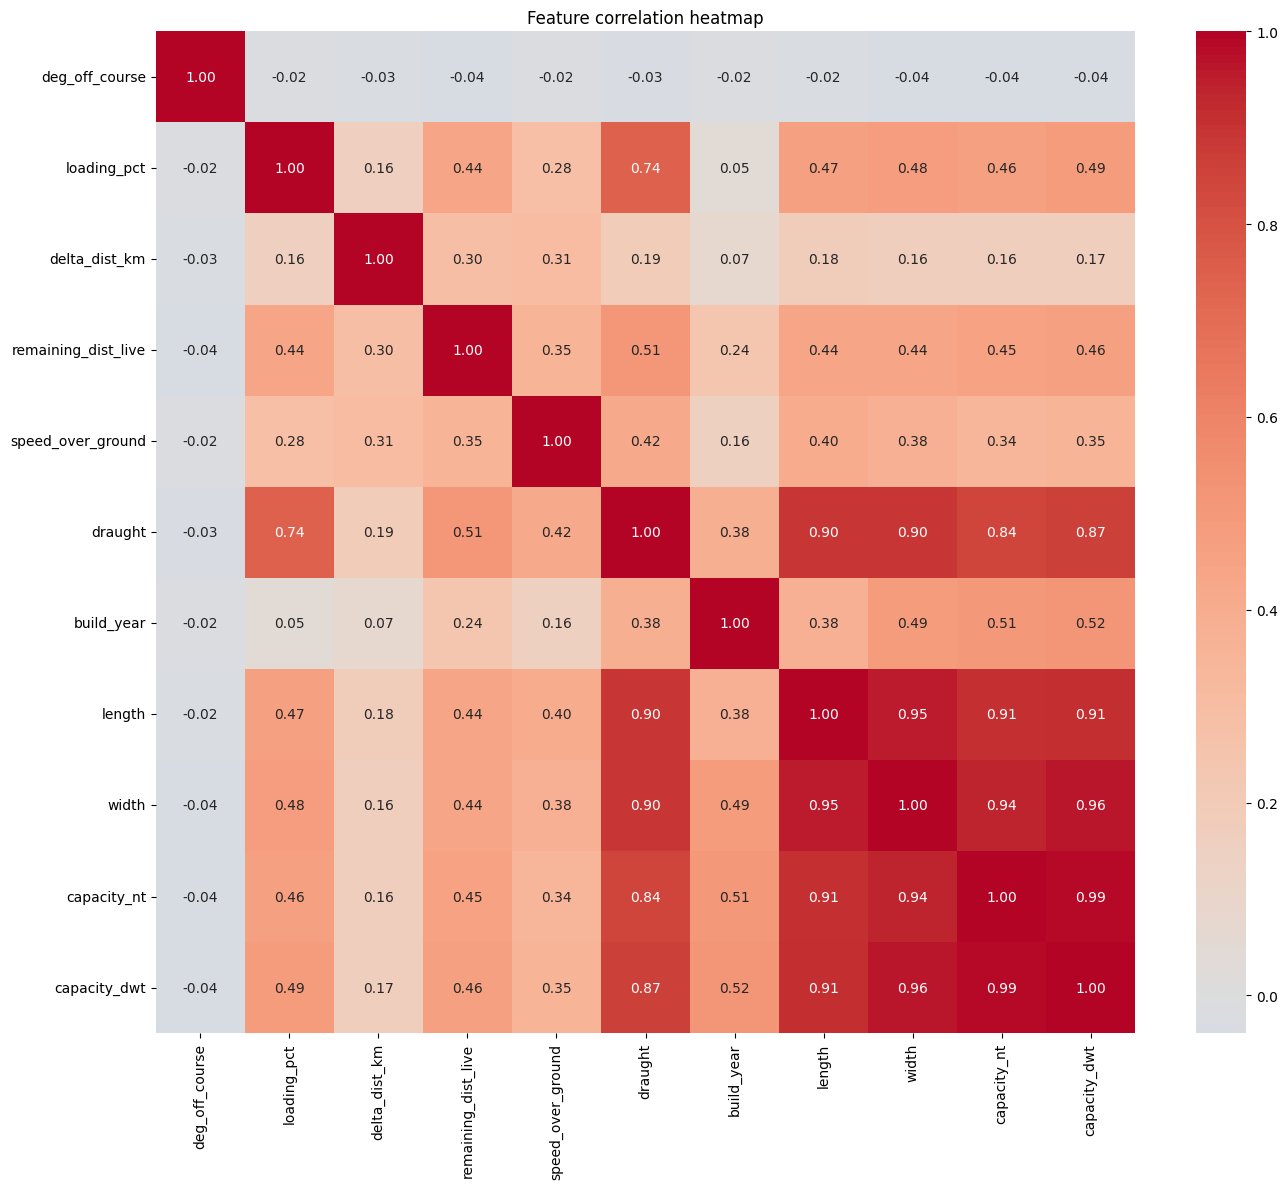

In [76]:
# seaborn correlation heatmap
import seaborn as sns

# 1) Select only numeric columns from your df (e.g. X_train)
num_df = features.select_dtypes(include=["number"])

# 2) Compute correlation matrix
corr = num_df.corr()

# 3) Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

We observe that draught, length, width, capacity_dwt, capacity_gw, capacity_teu, capacity_nt are all highly correlated.<br>
Perhaps we can combine these features into a singular feature.

## Export valid AIS samples to csv

In [ ]:
valid_voyage_ids = cargo_ais_meta_merged["voyage_id"].unique()
valid_voyage_ids_df = pd.DataFrame({"voyage_id": valid_voyage_ids})
valid_voyage_ids_df.shape

(2874, 1)

In [ ]:
valid_voyages_pct = valid_voyage_ids.shape[0]/len(arrivals_ais_data["voyage_id"].unique()) * 100
print(f"Valid voyages: {valid_voyages_pct:.2f}%")

Valid voyages: 6.63%


In [ ]:
valid_voyage_ids_df.to_csv(
    "unique_valid_voyages.csv",
    index=False,
    encoding="utf-8",
)

## Model development

In [77]:
# Convert month to numeric FIRST
features['month'] = pd.to_datetime(features['month']).dt.month  # '2024-01' → 1

# Verify
print(features['month'].dtype, features['month'].unique())

int32 [ 5  3  7  9  8 10  4  6 12  2  1 11]


/tmp/ipykernel_7014/1008346622.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['month'] = pd.to_datetime(features['month']).dt.month  # '2024-01' → 1


In [78]:
df_model = cargo_ais_meta_merged.copy()

# 1) Clean label first
#df_model = df_model[~df_model["tta_hours"].isna()]

# 2) Sort by time
# df_model = df_model.sort_values("pos_timestamp") # if we sort now, meta data and feature data has diverged, so might not line up in the same time space

# 3) Build X, y
X = features
y = df_model["tta_hours"]

# 4) Time-based split
split_idx = int(len(df_model) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]


In [79]:
X_train.shape

(358728, 16)

In [80]:
X_train.head()

,deg_off_course,voyage_status,navigation_status,loading_pct,position_accuracy,delta_dist_km,remaining_dist_live,speed_over_ground,draught,build_year,month,length,width,capacity_nt,capacity_dwt,position_device
0,-144.799988,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,NaN,606.904987,1.4,10.5,2005,5,207.0,30.0,12591,33796,GPS
1,173.899994,STOPPED,UNDER_WAY_USING_ENGINES,NaN,True,1.060671,607.957457,0.0,9.2,2005,5,207.0,30.0,12591,33796,GPS
2,-0.200000,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,0.291232,607.723237,5.7,9.2,2005,5,207.0,30.0,12591,33796,GPS
3,-15.399994,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,5.138737,604.692689,11.4,9.2,2005,5,207.0,30.0,12591,33796,GPS
4,0.699997,UNDER_WAY,UNDER_WAY_USING_ENGINES,NaN,True,5.581885,599.109514,13.3,9.2,2005,5,207.0,30.0,12591,33796,GPS


Learn the mean size of different commercial_size_class types to encode as numerical value (0-10 e.g.)
<br>one-hot encode navigation_status as ordinal value (no apparent ranking, just labels)

### TRY XGBOOST (handles np.nan directly) so no need to impute
<br>Scale data?

In [81]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358728 entries, 0 to 530227
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   deg_off_course       358728 non-null  float64
 1   voyage_status        358728 non-null  object 
 2   navigation_status    358728 non-null  object 
 3   loading_pct          225928 non-null  float64
 4   position_accuracy    358728 non-null  bool   
 5   delta_dist_km        356487 non-null  float64
 6   remaining_dist_live  358728 non-null  float64
 7   speed_over_ground    358728 non-null  float64
 8   draught              358728 non-null  float64
 9   build_year           358728 non-null  int64  
 10  month                358728 non-null  int32  
 11  length               358728 non-null  float64
 12  width                358728 non-null  float64
 13  capacity_nt          358728 non-null  int64  
 14  capacity_dwt         358728 non-null  int64  
 15  position_device      3

In [85]:
from xgboost import XGBRegressor

# convert object to categorical variable for xgboost
cat_cols = ["voyage_status", "navigation_status", "position_device"]

X_train = X_train.copy() # break slice diff
X_val   = X_val.copy()

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")

model_xgb = XGBRegressor(
    n_estimators=598,       # MORE trees
    max_depth=4,            # DEEPER trees
    learning_rate=0.01,       # FASTER learning
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.01,          # LIGHT L1 (lat/lon still matter)
    reg_lambda=1,
    min_child_weight=5,      # Fight outliers
    tree_method='hist',
    enable_categorical=True,
    n_jobs=28,
    random_state=42,
    early_stopping_rounds=50 # Auto-stop
)

model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)


#model_xgb.fit(X_train, y_train)  # Raw df! No preprocess needed
print(f"Top features: \n{pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)}")


[0]	validation_0-rmse:140.78695
[100]	validation_0-rmse:69.75678
[200]	validation_0-rmse:53.57479
[300]	validation_0-rmse:51.72250
[303]	validation_0-rmse:51.84364
Top features: 
remaining_dist_live    0.286662
length                 0.249724
delta_dist_km          0.106205
month                  0.080951
draught                0.060968
navigation_status      0.045348
width                  0.031934
speed_over_ground      0.028640
capacity_dwt           0.026148
loading_pct            0.024924
position_accuracy      0.017297
deg_off_course         0.015137
build_year             0.013136
capacity_nt            0.012927
voyage_status          0.000001
position_device        0.000000
dtype: float32


## Model evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model_xgb.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE (hours): {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²: {r2:.2f}")

errors = y_pred - y_val
print(f"\nErrors (hours): \n{errors.describe().round(2)}")

MAE (hours): 24.74
RMSE (hours): 51.41
R²: 0.86

Errors (hours): 
count    89683.00
mean         9.16
std         50.59
min       -282.87
25%          2.70
50%         13.54
75%         20.33
max        759.66
Name: tta_hours, dtype: float64


Mean Average Error: on average off by, e.g. 25 hours.
<br>RMSE: a few huge errors (>600 hours) ruining it
<br>Mean: bias, e.g. 8 hours too late. Can add as offset.

Find biggest error voyage ids

In [102]:
voyage_id_map = cargo_ais_meta_merged[['voyage_id', 'pos_timestamp']].loc[X_val.index].copy()

errors_df = pd.DataFrame({
    'voyage_id': voyage_id_map['voyage_id'],
    'pos_timestamp': voyage_id_map['pos_timestamp'],
    'predicted': y_pred,
    'actual': y_val,        
    'error': y_pred - y_val
})

# Worst voyages
print("Worst underpredictions:")
print(errors_df.nsmallest(10, 'error')[['voyage_id', 'error', 'predicted', 'actual']])

print("\nWorst overpredictions:")
print(errors_df.nlargest(10, 'error')[['voyage_id', 'error', 'predicted', 'actual']])


Worst underpredictions:
                                   voyage_id       error   predicted  \
618667  e90818f1-1226-4c05-ad22-b2ae31f3067e -282.872513  357.316376   
618668  e90818f1-1226-4c05-ad22-b2ae31f3067e -282.522513  357.316376   
618666  e90818f1-1226-4c05-ad22-b2ae31f3067e -282.487379  358.065399   
618669  e90818f1-1226-4c05-ad22-b2ae31f3067e -282.186124  357.316376   
618670  e90818f1-1226-4c05-ad22-b2ae31f3067e -281.830569  357.316376   
618671  e90818f1-1226-4c05-ad22-b2ae31f3067e -281.761326  357.018951   
618672  e90818f1-1226-4c05-ad22-b2ae31f3067e -280.761653  357.670013   
618686  e90818f1-1226-4c05-ad22-b2ae31f3067e -279.121744  338.854645   
618674  e90818f1-1226-4c05-ad22-b2ae31f3067e -279.065713  358.407898   
561974  d2f78595-6cbd-4523-a958-c8a56ac3c6c3 -273.595632  322.213257   

            actual  
618667  640.188889  
618668  639.838889  
618666  640.552778  
618669  639.502500  
618670  639.146944  
618671  638.780278  
618672  638.431667  
618686  617.976

Worst OVERprediction:

/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


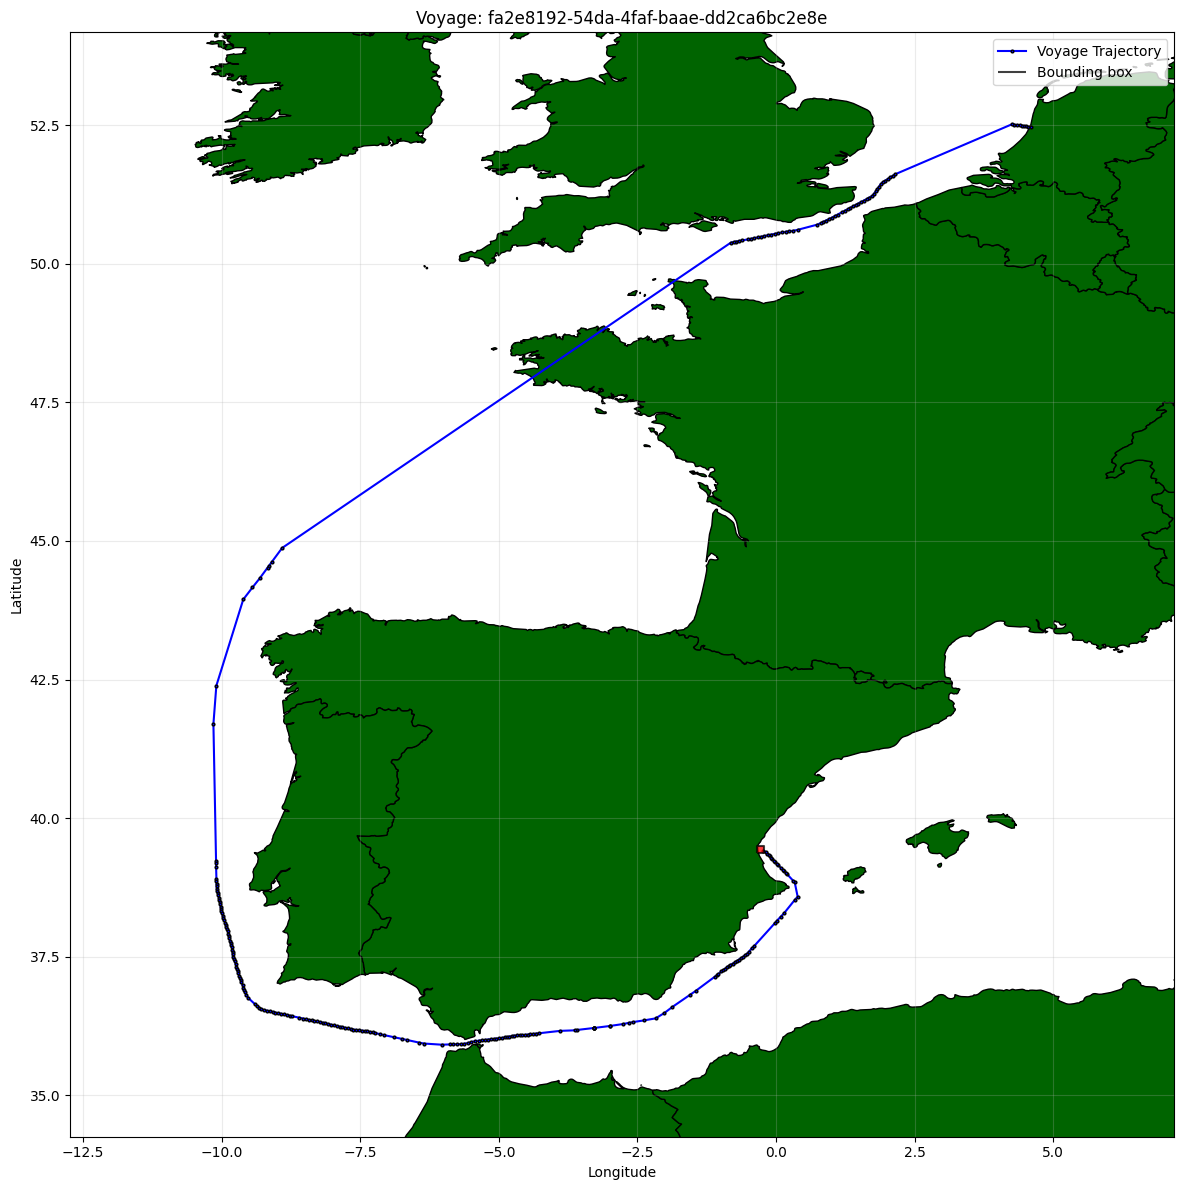

Voyage: fa2e8192-54da-4faf-baae-dd2ca6bc2e8e 
Total traveled distance: 2890.17 km
Duration: 215.17 hours
Data points: 269


In [253]:
sus_voyage_id = "fa2e8192-54da-4faf-baae-dd2ca6bc2e8e"
sus_voyage_df = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == sus_voyage_id]
plot_voyage_on_coastline(sus_voyage_df, coastline, BBOX)

Worst UNDERprediction:

/tmp/ipykernel_7014/569726036.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


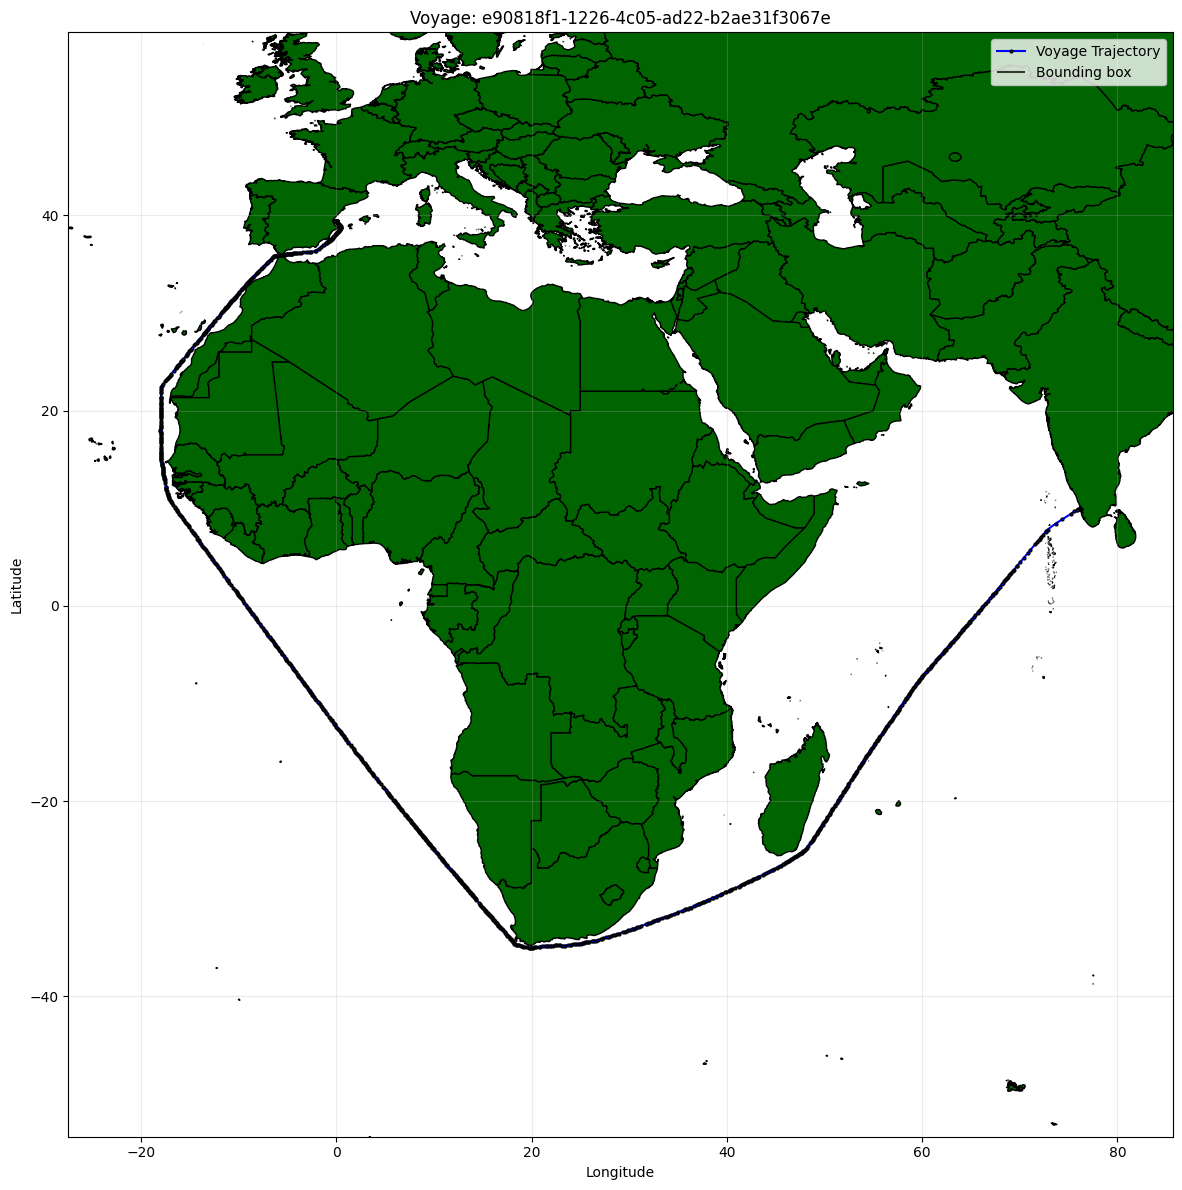

Voyage: e90818f1-1226-4c05-ad22-b2ae31f3067e 
Total traveled distance: 18414.73 km
Duration: 642.89 hours
Data points: 1184


In [254]:
sus_voyage_id2 = "e90818f1-1226-4c05-ad22-b2ae31f3067e"
sus_voyage_df2 = cargo_ais_meta_merged[cargo_ais_meta_merged["voyage_id"] == sus_voyage_id2]
plot_voyage_on_coastline(sus_voyage_df2, coastline, BBOX)

In [87]:
pct_24hr = np.mean(np.abs(errors) < 24) * 100
print(f"Within 24hr: {pct_24hr:.1f}%")

Within 24hr: 73.6%


In [ ]:
#import joblib
#joblib.dump(model_xgb, "xgb_0.joblib")

In [ ]:
#import joblib
#model = joblib.load("xgb_0.joblib")